# Stage Transition Model

**Goal:** At each stage transition, predict:
- `P(advances to next stage | current stage)` 
- `P(lost | current stage) = 1 - P(advances)`

Dataset: `stage_transitions_model_v2.csv` — one row per actual stage transition from stages 1-7, labeled `advanced=1` (moved forward) or `advanced=0` (moved to closed-lost).

Rebuilt by `scripts/build_transition_model_set.sql` from `stage_transition_snapshots.csv`. Same 3,968 rows as the original file, with three changes:

- **`meetings_conducted` is higher on 1,302 rows.** The old build read `fact_link`, which is a rolling window holding only 10,263 of the 31,735 meeting→opportunity edges. It now unions `dim_link` as well.
- **`stall_ratio` is imputed per stage.** 490 rows have no usable `days_in_sales_cycle`. The old file filled them from a global mean (~0.87); this fills from the stage-conditional weighted mean, which runs 0.99 at `1-profile` down to 0.27 at `7-submit_for_close`. `stall_ratio_imputed` flags those rows.
- **12 `sig_*` columns** carry LLM signals from the meetings held *before* each transition (34.4% of rows). `sig_count = 0` where no meeting had a usable transcript.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from sklearn.metrics import (
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    brier_score_loss,
    classification_report,
    precision_recall_curve
)
from sklearn.calibration import calibration_curve
from catboost import CatBoostClassifier

In [2]:
df = pd.read_csv("stage_transitions_model_v2.csv")
print(f"Rows: {len(df)}, Unique opps: {df['opportunity_id'].nunique()}")
print(f"Rows with meeting signals: {(df['sig_count'] > 0).sum()} "
      f"({(df['sig_count'] > 0).mean():.1%})")
display(df.head())

Rows: 3968, Unique opps: 3091
Rows with meeting signals: 1364 (34.4%)


,opportunity_id,display_id,snapshot_version,snapshot_date,current_stage,next_stage,opportunity_type,segment,days_in_current_stage,days_in_sales_cycle,...,sig_sentiment_last,sig_sentiment_first,sig_sentiment_min,sig_sentiment_max,sig_pain_any,sig_pain_rate,sig_pricing_any,sig_pricing_rate,sig_confidence_mean,sig_days_since_last_scored
0,don:core:dvrv-us-1:devo/0:opportunity/10000,OPP-10000,213,2026-07-14 18:39:24.051,3-evaluate,9-closed_lost,New,Enterprise,76.0,134.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,don:core:dvrv-us-1:devo/0:opportunity/10002,OPP-10002,103,2026-05-26 03:49:58.517,1-profile,9-closed_lost,New,Mid-Market,84.0,84.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,don:core:dvrv-us-1:devo/0:opportunity/10006,OPP-10006,141,2026-05-27 13:55:54.875,3-evaluate,5-validate,New,SMB,86.0,86.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,don:core:dvrv-us-1:devo/0:opportunity/10011,OPP-10011,79,2026-05-14 00:21:52.017,1-profile,9-closed_lost,New,Enterprise,71.0,71.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,don:core:dvrv-us-1:devo/0:opportunity/10014,OPP-10014,238,2026-06-17 04:58:42.848,3-evaluate,5-validate,New,Enterprise,54.0,105.0,...,0.58,0.62,0.58,0.62,1.0,1.0,1.0,1.0,0.86,29.0


In [3]:
print("\nLabel distribution:")
print(df["advanced"].value_counts())
print(f"\nAdvance rate: {df['advanced'].mean():.3f}")


Label distribution:
advanced
0    2492
1    1476
Name: count, dtype: int64

Advance rate: 0.372


In [4]:
print("\nBy current stage:")
display(
    df.groupby("current_stage")["advanced"]
      .agg(["count", "sum", "mean"])
      .rename(columns={"count": "transitions", "sum": "advanced", "mean": "advance_rate"})
      .sort_index()
)


By current stage:


,transitions,advanced,advance_rate
current_stage,,,
1-profile,2626,893,0.340061
2-qualify,629,209,0.332273
3-evaluate,370,135,0.364865
4-go_no_go,93,57,0.612903
5-validate,101,63,0.623762
6-negotiate,83,55,0.662651
7-submit_for_close,66,64,0.969697


In [118]:
print("\nMissing values:")
print(df.isnull().sum().sort_values(ascending=False))


Missing values:
days_in_current_stage    462
days_in_sales_cycle      462
segment                  267
opportunity_id             0
display_id                 0
snapshot_version           0
snapshot_date              0
current_stage              0
next_stage                 0
opportunity_type           0
stall_ratio                0
has_champion               0
contract_length            0
advanced                   0
meetings_conducted         0
dtype: int64


## Feature Setup

In [13]:
BASE_FEATURES = [
    "current_stage",
    "opportunity_type",
    "segment",
    "stall_ratio",
    "has_champion",
    "contract_length",
    "days_in_current_stage",
    "days_in_sales_cycle",
    "meetings_conducted",
]

# LLM signals from the meetings held before each transition. NaN on the 65.6%
# of rows with no scored meeting -- left as NaN because CatBoost splits on
# missingness directly, and "no meeting was scored" is itself informative.
SIGNAL_FEATURES = [
    # "sig_count",
    "sig_sentiment_mean",
    "sig_sentiment_last",
    "sig_sentiment_min",
    "sig_pain_any",
    "sig_pricing_any",
    "sig_confidence_mean",
]

# flip to False to reproduce the pre-signal baseline on the same rows
USE_SIGNALS = True

feature_columns = BASE_FEATURES + (SIGNAL_FEATURES if USE_SIGNALS else [])

categorical_features = ["current_stage", "opportunity_type", "segment"]
numeric_features = [c for c in feature_columns if c not in categorical_features]

X = df[feature_columns].copy()
y = df["advanced"].astype(int)
groups = df["opportunity_id"]

# CatBoost prep
for col in categorical_features:
    X[col] = X[col].fillna("UNKNOWN").astype(str)

for col in numeric_features:
    X[col] = pd.to_numeric(X[col], errors="coerce")

print(f"X: {X.shape}, y: {y.shape}")
print(f"Groups: {groups.nunique()} unique opportunities")

X: (3968, 15), y: (3968,)
Groups: 3091 unique opportunities


## Cross-Validation (GroupKFold)

In [14]:
gkf = GroupKFold(n_splits=5)
folds = list(gkf.split(X, y, groups))

for fold_num, (train_idx, test_idx) in enumerate(folds, 1):
    train_opps = set(groups.iloc[train_idx])
    test_opps = set(groups.iloc[test_idx])
    overlap = train_opps & test_opps
    print(f"Fold {fold_num}: train={len(train_opps)} opps, test={len(test_opps)} opps, overlap={len(overlap)}")

Fold 1: train=2473 opps, test=618 opps, overlap=0
Fold 2: train=2473 opps, test=618 opps, overlap=0
Fold 3: train=2472 opps, test=619 opps, overlap=0
Fold 4: train=2473 opps, test=618 opps, overlap=0
Fold 5: train=2473 opps, test=618 opps, overlap=0


## CatBoost Training

In [15]:
results = []
all_oof = []

for fold_num, (train_idx, test_idx) in enumerate(folds, 1):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    model = CatBoostClassifier(
        iterations=500,
        depth=5,
        learning_rate=0.03,
        loss_function="Logloss",
        eval_metric="PRAUC",
        auto_class_weights="Balanced",
        l2_leaf_reg=5,
        random_seed=42,
        verbose=False,
    )

    model.fit(X_train, y_train, cat_features=categorical_features)

    probs = model.predict_proba(X_test)[:, 1]  # P(advanced)
    preds = (probs >= 0.5).astype(int)

    metrics = {
        "fold": fold_num,
        "PR_AUC": average_precision_score(y_test, probs),
        "ROC_AUC": roc_auc_score(y_test, probs),
        "Precision": precision_score(y_test, preds, zero_division=0),
        "Recall": recall_score(y_test, preds, zero_division=0),
        "F1": f1_score(y_test, preds, zero_division=0),
        "Brier": brier_score_loss(y_test, probs),
    }
    results.append(metrics)

    all_oof.append(pd.DataFrame({
        "opportunity_id": groups.iloc[test_idx].values,
        "current_stage": df["current_stage"].iloc[test_idx].values,
        "actual": y_test.values,
        "p_advance": probs,
        "p_lost": 1 - probs,
        "fold": fold_num,
    }))

results_df = pd.DataFrame(results)
display(results_df)

,fold,PR_AUC,ROC_AUC,Precision,Recall,F1,Brier
0,1,0.854510,0.900161,0.748387,0.800000,0.773333,0.127928
1,2,0.846876,0.886228,0.739812,0.776316,0.757624,0.135355
2,3,0.852890,0.894344,0.758958,0.787162,0.772803,0.126877
3,4,0.808688,0.876026,0.722408,0.757895,0.739726,0.139426
4,5,0.837965,0.885406,0.744027,0.724252,0.734007,0.133555


In [16]:
print("\nMean ± Std:")
display(results_df[["PR_AUC","ROC_AUC","Precision","Recall","F1","Brier"]].agg(["mean","std"]))


Mean ± Std:


,PR_AUC,ROC_AUC,Precision,Recall,F1,Brier
mean,0.840186,0.888433,0.742718,0.769125,0.755499,0.132628
std,0.018764,0.009226,0.013403,0.029453,0.018253,0.005236


## Feature Importance

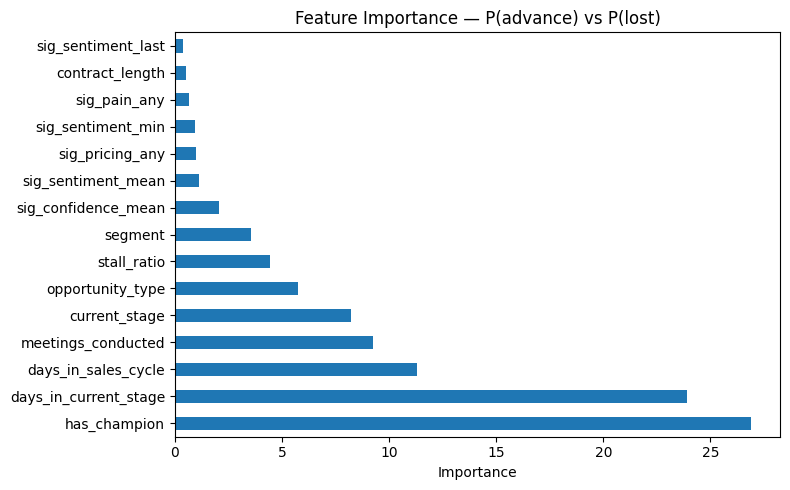

has_champion             26.907560
days_in_current_stage    23.915644
days_in_sales_cycle      11.324075
meetings_conducted        9.238779
current_stage             8.230515
opportunity_type          5.755430
stall_ratio               4.445636
segment                   3.531553
sig_confidence_mean       2.076685
sig_sentiment_mean        1.140423
sig_pricing_any           0.988927
sig_sentiment_min         0.912045
sig_pain_any              0.662823
contract_length           0.516883
sig_sentiment_last        0.353022
dtype: float64


In [17]:
# Retrain on full data for feature importance
final_model = CatBoostClassifier(
    iterations=500,
    depth=5,
    learning_rate=0.03,
    loss_function="Logloss",
    eval_metric="PRAUC",
    auto_class_weights="Balanced",
    l2_leaf_reg=5,
    random_seed=42,
    verbose=False,
)
final_model.fit(X, y, cat_features=categorical_features)

importance = pd.Series(
    final_model.feature_importances_,
    index=feature_columns
).sort_values(ascending=False)

plt.figure(figsize=(8, 5))
importance.plot(kind="barh")
plt.xlabel("Importance")
plt.title("Feature Importance — P(advance) vs P(lost)")
plt.tight_layout()
plt.show()

print(importance)

## Calibration

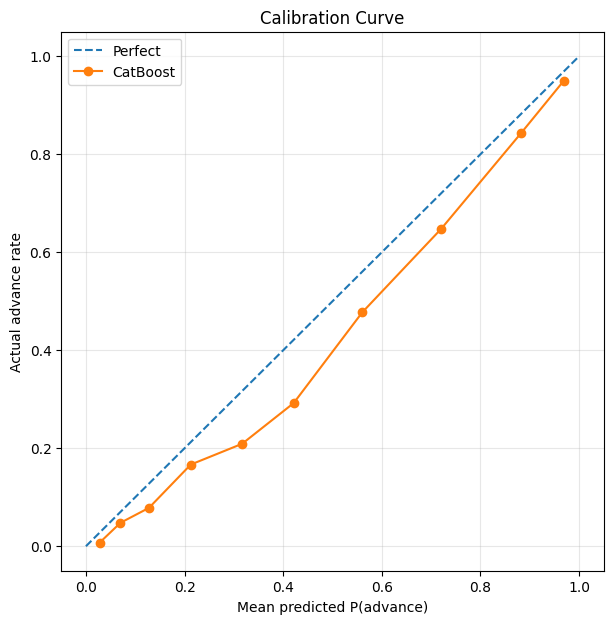

Overall Brier: 0.1326


In [18]:
oof_df = pd.concat(all_oof, ignore_index=True)

# Calibration curve
prob_true, prob_pred = calibration_curve(
    oof_df["actual"], oof_df["p_advance"], n_bins=10, strategy="quantile"
)

plt.figure(figsize=(7, 7))
plt.plot([0, 1], [0, 1], "--", label="Perfect")
plt.plot(prob_pred, prob_true, "o-", label="CatBoost")
plt.xlabel("Mean predicted P(advance)")
plt.ylabel("Actual advance rate")
plt.title("Calibration Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"Overall Brier: {brier_score_loss(oof_df['actual'], oof_df['p_advance']):.4f}")

## Per-Stage Predictions

In [19]:
stage_perf = (
    oof_df.groupby("current_stage")
    .agg(
        n=("actual", "size"),
        actual_advance_rate=("actual", "mean"),
        mean_p_advance=("p_advance", "mean"),
        mean_p_lost=("p_lost", "mean"),
    )
    .sort_index()
)
display(stage_perf)

,n,actual_advance_rate,mean_p_advance,mean_p_lost
current_stage,,,,
1-profile,2626,0.340061,0.393664,0.606336
2-qualify,629,0.332273,0.418303,0.581697
3-evaluate,370,0.364865,0.440410,0.559590
4-go_no_go,93,0.612903,0.693996,0.306004
5-validate,101,0.623762,0.699403,0.300597
6-negotiate,83,0.662651,0.680499,0.319501
7-submit_for_close,66,0.969697,0.879607,0.120393


In [20]:
# Output: two-column prediction table
print("\nSample predictions (P(advance) and P(lost) per transition):")
display(oof_df[["opportunity_id","current_stage","actual","p_advance","p_lost"]].head(15))


Sample predictions (P(advance) and P(lost) per transition):


,opportunity_id,current_stage,actual,p_advance,p_lost
0,don:core:dvrv-us-1:devo/0:opportunity/10019,1-profile,0,0.037951,0.962049
1,don:core:dvrv-us-1:devo/0:opportunity/10032,2-qualify,0,0.395255,0.604745
2,don:core:dvrv-us-1:devo/0:opportunity/10036,5-validate,1,0.803862,0.196138
3,don:core:dvrv-us-1:devo/0:opportunity/10036,6-negotiate,1,0.913029,0.086971
4,don:core:dvrv-us-1:devo/0:opportunity/10036,7-submit_for_close,1,0.973283,0.026717
5,don:core:dvrv-us-1:devo/0:opportunity/10050,2-qualify,0,0.211611,0.788389
6,don:core:dvrv-us-1:devo/0:opportunity/10055,1-profile,0,0.012437,0.987563
7,don:core:dvrv-us-1:devo/0:opportunity/10060,3-evaluate,0,0.228852,0.771148
8,don:core:dvrv-us-1:devo/0:opportunity/10070,1-profile,0,0.022133,0.977867
9,don:core:dvrv-us-1:devo/0:opportunity/10082,3-evaluate,0,0.521637,0.478363
